# CONTOURS IN IMAGES
## This notebook outlines the concepts used in Contours in the field of Image Processing

## Contours

A contour is a **curve of points**, with **no gaps** in the curve

To find contours in an image:
- Obtain the **binarization** of the image
    - edge detection methods
    - thresholding methods


### Steps
- Import the necessary libraries
- Load the image
- Convert the image into Grayscale
- Blur the image
- Apply edge detection methods
    - Use Canny()
- Find contours
    - Use cv2.findContours()
- Draw the contours
- Display the drawn contours

#### Import the libraries

In [1]:
import cv2
import numpy as np

#### Load the image

In [9]:
image = cv2.imread("coins.jpg")

#### Convert the image into Grayscale

In [12]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#### Blur the image

In [15]:
blurred = cv2.GaussianBlur(gray, (9, 9), 0)

#### Apply Canny Edge Detection

In [18]:
edged = cv2.Canny(blurred, 30, 150)

#### Display intermediate results

In [21]:
cv2.imshow("Contour_Interim", np.hstack([gray, blurred, edged]))
cv2.waitKey(0)

-1

#### Find Contours

**cv2.findContours()**
- image (recommeded to send its copy rather the original)
- type of contour
    - cv2.RETR_EXTERNAL
    - cv2.RETR_LIST
    - cv2.RETR_COMP
    - cv2.RETR_TREE
- approximation of contour
    - cv2.CHAIN_APPROX_SIMPLE
    - cv2.CHAIN_APPROX_NONE
- Returns a tuple
    - output image after applying contour detection
    - cnts list of contours detected
    - hierarchy of the contours

In [23]:
(cnts, _) = cv2.findContours(edged.copy(), 
                             cv2.RETR_EXTERNAL, 
                             cv2 .CHAIN_APPROX_SIMPLE
)

#### Draw the Contours
cv2.drawContours()
- image
- contours list
- contour index
    - -1 --> draw all of the contours
    - i --> draw single contour
- color of the contour line
    - Use green color
- thickness of the line

In [26]:
coins = image.copy()
cv2.drawContours(coins, cnts, -1, (0, 255, 0), 2)

array([[[148, 159, 172],
        [149, 160, 174],
        [150, 162, 175],
        ...,
        [175, 190, 203],
        [173, 188, 202],
        [172, 188, 200]],

       [[148, 160, 172],
        [152, 164, 176],
        [151, 162, 175],
        ...,
        [176, 192, 204],
        [174, 189, 203],
        [171, 186, 201]],

       [[148, 160, 172],
        [152, 162, 174],
        [150, 162, 174],
        ...,
        [176, 192, 206],
        [174, 190, 203],
        [172, 186, 201]],

       ...,

       [[163, 172, 184],
        [162, 171, 181],
        [159, 170, 179],
        ...,
        [189, 202, 212],
        [191, 203, 213],
        [190, 202, 213]],

       [[161, 170, 182],
        [160, 169, 180],
        [160, 170, 181],
        ...,
        [191, 203, 215],
        [192, 204, 214],
        [191, 203, 214]],

       [[158, 167, 181],
        [161, 170, 183],
        [162, 171, 185],
        ...,
        [190, 202, 214],
        [191, 203, 213],
        [192, 204, 216]]

#### Display the Contours

In [29]:
cv2.imshow("Coins", np.hstack([image, coins]))
cv2.waitKey(0)

-1

In [31]:
len(cnts)

9

## Grab each coin

In [34]:
for (i, c) in enumerate(cnts):
    (x, y, w, h) = cv2.boundingRect(c)
    print("Coin #{}".format(i + 1))
    coin = image[y:y + h, x:x + w]
    cv2.imshow("Coin", coin)
    
    mask = np.zeros(image.shape[:2], dtype = "uint8")
    ((centerX, centerY), radius) = cv2.minEnclosingCircle(c)
    
    cv2.circle(mask, (int(centerX), int(centerY)), int(radius), 255, -1)
    mask = mask[y:y + h, x:x + w]
    cv2.imshow("Masked Coin", cv2.bitwise_and(coin, coin, mask = mask))
    cv2.waitKey(0)

Coin #1
Coin #2
Coin #3
Coin #4
Coin #5
Coin #6
Coin #7
Coin #8
Coin #9


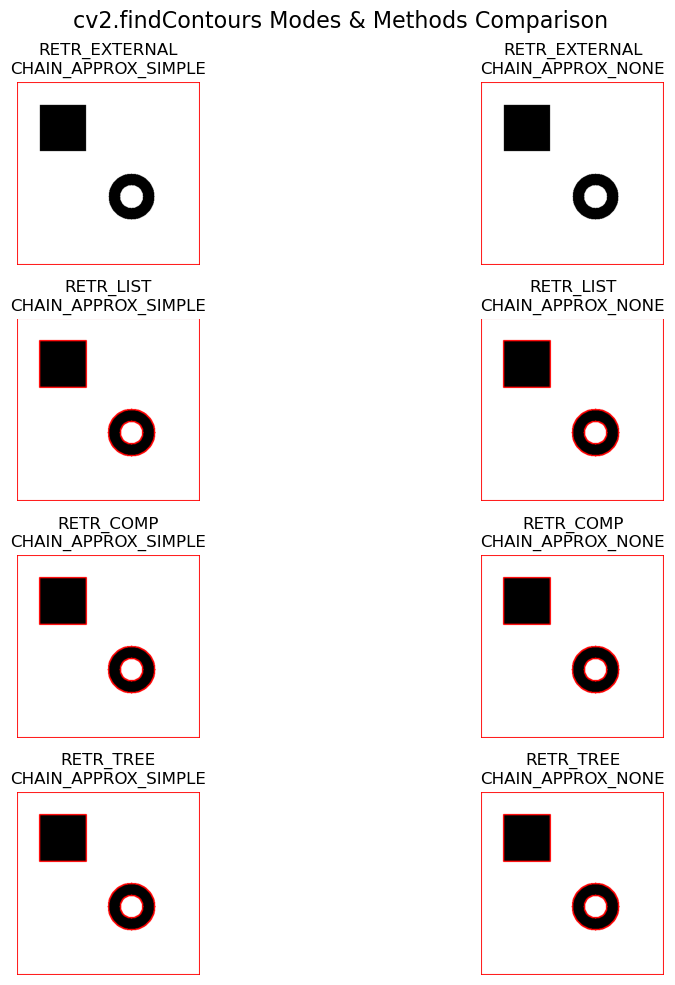

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 建立一張簡單圖像：白色背景 + 黑色圓 + 黑色矩形 + 黑色內孔
image = np.ones((400, 400), dtype="uint8") * 255
cv2.rectangle(image, (50, 50), (150, 150), 0, -1)
cv2.circle(image, (250, 250), 50, 0, -1)
cv2.circle(image, (250, 250), 25, 255, -1)  # 內孔

# 轉成 BGR（之後用來畫輪廓）
original_bgr = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

# 所有 combinations（mode x method）
modes = {
    "RETR_EXTERNAL": cv2.RETR_EXTERNAL,
    "RETR_LIST": cv2.RETR_LIST,
    "RETR_COMP": cv2.RETR_CCOMP,
    "RETR_TREE": cv2.RETR_TREE
}

methods = {
    "CHAIN_APPROX_SIMPLE": cv2.CHAIN_APPROX_SIMPLE,
    "CHAIN_APPROX_NONE": cv2.CHAIN_APPROX_NONE
}

# 畫圖
fig, axs = plt.subplots(len(modes), len(methods), figsize=(12, 10))
fig.suptitle("cv2.findContours Modes & Methods Comparison", fontsize=16)

for row_idx, (mode_name, mode) in enumerate(modes.items()):
    for col_idx, (method_name, method) in enumerate(methods.items()):
        image_copy = image.copy()
        cnts, hierarchy = cv2.findContours(image_copy, mode, method)
        output = original_bgr.copy()
        cv2.drawContours(output, cnts, -1, (0, 0, 255), 2)

        axs[row_idx, col_idx].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        axs[row_idx, col_idx].set_title(f"{mode_name}\n{method_name}")
        axs[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()


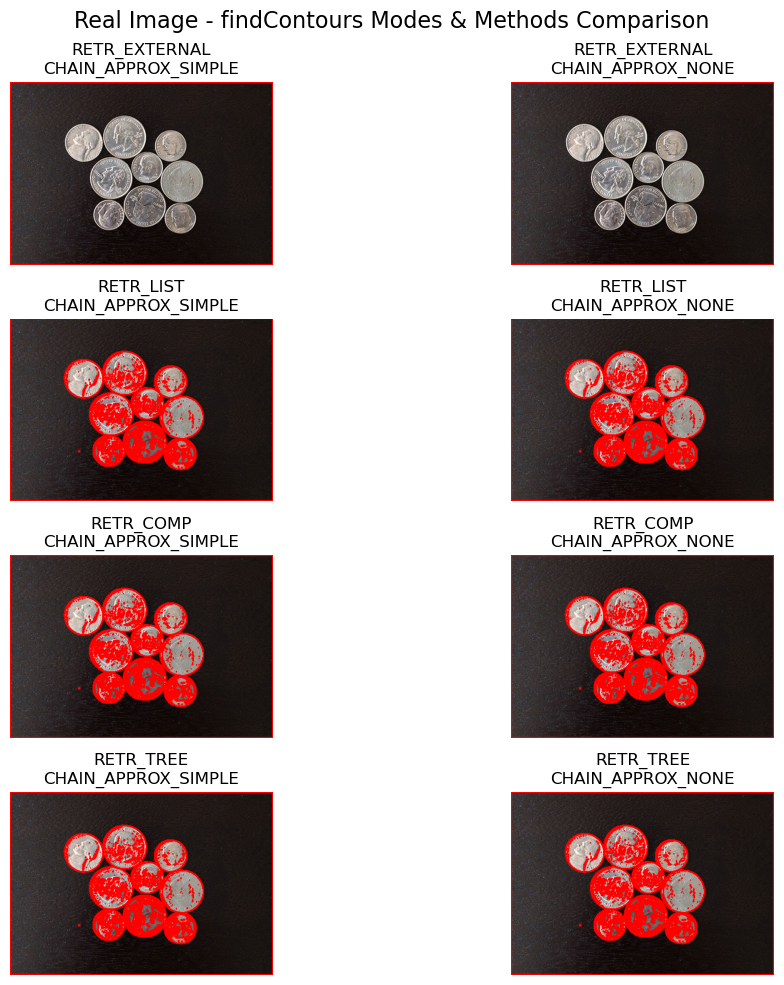

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 讀取實際圖像（記得換成你自己的檔名）
image_path = 'coins_overlap.jpg'
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 二值化處理（可換成 Canny 等方式）
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# 組合方式
modes = {
    "RETR_EXTERNAL": cv2.RETR_EXTERNAL,
    "RETR_LIST": cv2.RETR_LIST,
    "RETR_COMP": cv2.RETR_CCOMP,
    "RETR_TREE": cv2.RETR_TREE
}

methods = {
    "CHAIN_APPROX_SIMPLE": cv2.CHAIN_APPROX_SIMPLE,
    "CHAIN_APPROX_NONE": cv2.CHAIN_APPROX_NONE
}

# 顯示圖表
fig, axs = plt.subplots(len(modes), len(methods), figsize=(12, 10))
fig.suptitle("Real Image - findContours Modes & Methods Comparison", fontsize=16)

for row_idx, (mode_name, mode) in enumerate(modes.items()):
    for col_idx, (method_name, method) in enumerate(methods.items()):
        image_copy = thresh.copy()
        cnts, hierarchy = cv2.findContours(image_copy, mode, method)

        output = image.copy()
        cv2.drawContours(output, cnts, -1, (0, 0, 255), 2)

        axs[row_idx, col_idx].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        axs[row_idx, col_idx].set_title(f"{mode_name}\n{method_name}")
        axs[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()


### Bonus Helper function to use old version codebase

### grab_contours( )

In [36]:
def grab_contours(cnts): 
    if len(cnts) == 2: 
        cnts = cnts[0]
    elif len(cnts) == 3:
        cnts = cnts[1]
    else:
        raise Exception(("Contours tuple must have length 2 or "
                        "3, otherwise OpenCV changed their cv2.findContours " 
                        "return signature yet again. "
                        "Refer to OpenCV’s documentation in that case."))
    return cnts